In [1]:
import pandas as pd
import numpy as np
from glob import glob

import arcgis
from arcgis.features import SpatialDataFrame
from arcgis.features.use_proximity import find_nearest

In [2]:
gis = GIS("https://geosaurus.maps.arcgis.com/", "rsingh_geosaurus", "P@ssw0rd@123")

In [20]:
root = r'c:/xc/github/zika' 

## Places with confirmed Zika infections

Uses CDC Epidemic Prediction Initiative's repository of publicly available Zika data - https://github.com/cdcepi/zika

In [3]:
location_files = glob(root +'/*/*Places.csv')

In [4]:
locations = pd.concat([pd.read_csv(x, encoding="ISO-8859-1")
                       for x in location_files], axis=0).reset_index(drop=True)

In [5]:
locations.head(1)

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province
0,Buenos Aires,BUENOS AIRES,NaN,Argentina,NaN,Argentina-Buenos_Aires,province,Buenos Aires


In [6]:
# clean up
locations.fillna('', inplace=True)
locations['country'] = locations.country.str.replace('_', ' ')

cols = locations.select_dtypes(include=[np.object]).columns
locations[cols] = locations[cols].apply(
    lambda x: x.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))

### Create address column

In [85]:
def get_address(location):
    addr_parts = location.split('-')
    addr = addr_parts[-1].replace('_', ' ')
    for part in addr_parts[-2::-1]:
        addr += ', ' + part.replace('_', ' ')
    return addr

In [8]:
locations['address'] = locations['location'].apply(get_address)

In [9]:
locations.head(1)

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address
0,Buenos Aires,BUENOS AIRES,,Argentina,,Argentina-Buenos_Aires,province,Buenos Aires,"Buenos Aires, Argentina"


### Create spatial dataframe

Create a spatially enabled dataframe, save it as a shapefile, and also import it into the GIS

In [10]:
spdf = SpatialDataFrame.from_df(locations)

In [11]:
spdf.sr = arcgis.geometry.SpatialReference(wkid=4326)

In [12]:
spdf.head()

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address,SHAPE
0,Buenos Aires,BUENOS AIRES,,Argentina,,Argentina-Buenos_Aires,province,Buenos Aires,"Buenos Aires, Argentina","{'x': -58.37343999999996, 'y': -34.60848999999..."
1,CABA,CABA,,Argentina,,Argentina-CABA,province,CABA,"CABA, Argentina","{'x': -58.37343999999996, 'y': -34.60848999999..."
2,Cordoba,CORDOBA,,Argentina,,Argentina-Cordoba,province,Cordoba,"Cordoba, Argentina","{'x': -64.18570999999997, 'y': -31.40717999999..."
3,Entre Rios,ENTRE RIOS,,Argentina,,Argentina-Entre_Rios,province,Entre Rios,"Entre Rios, Argentina","{'x': -59.200252396999986, 'y': -32.0606035709..."
4,Santa Fe,SANTA FE,,Argentina,,Argentina-Santa_Fe,province,Santa Fe,"Santa Fe, Argentina","{'x': -60.71202999999997, 'y': -31.63664999999..."


In [14]:
spdf.to_featureclass(out_location=root,
                         out_name="zika_locations.shp")

'c:/xc/github/zika\\zika_locations.shp'

In [15]:
zika_loc = gis.content.import_data(spdf, title='Locations with Zika')

In [16]:
zika_loc

<Item title:"Locations with Zika" type:Feature Layer Collection owner:rsingh_geosaurus>

In [69]:
zika_loc.itemid

'adb3f72bd0eb49c7b8f6a7b7d16cadae'

## Load Zika locations feature layer

In [3]:
zika_loc = gis.content.get('adb3f72bd0eb49c7b8f6a7b7d16cadae')

In [4]:
zikalyr = zika_loc.layers[0]

### Map locations of zika infections

In [5]:
m = gis.map('USA')
m

In [6]:
m.add_layer(zika_loc)

## Find airports nearest to Zika locations

### Load Airport locations

<Item title:"World Airport Locations" type:Feature Layer Collection owner:garycjohnsonDP>
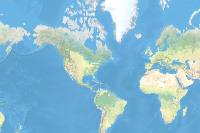

In [7]:
airports = gis.content.search('title: World Airport Locations owner:garycjohnsonDP', 'Feature Layer', outside_org=True)[0]
airports

In [8]:
airportlyr = airports.layers[0]

In [9]:
airportsdf = SpatialDataFrame.from_layer(airportlyr)

In [10]:
zikadf = zikalyr.query().df

In [11]:
zikadf.country.unique()

array(['Colombia', 'Dominican Republic', 'Ecuador', 'El Salvador',
       'France', 'Guatemala', 'Haiti', 'Mexico', 'Nicaragua', 'Panama',
       'United States', 'Argentina', 'Brazil'], dtype=object)

In [12]:
zikadf.columns

Index(['FID', 'address', 'alt_name1', 'alt_name2', 'city', 'country',
       'district_c', 'location', 'location_t', 'state_prov', 'SHAPE'],
      dtype='object')

### Find Nearest Airports from Zika locations using Spatial Analysis

In [13]:
def find_nearest_airports(location_filter, airport_filter):
    zikalyr.filter = location_filter
    airportlyr.filter = airport_filter
    
    nearest_airports = find_nearest(zikalyr, airportlyr, 'StraightLine', max_count=1,
                                    search_cutoff=100, search_cutoff_units='Miles')

    m.add_layer(nearest_airports['nearest_layer'])
    m.add_layer(nearest_airports['connecting_lines_layer'])
    
    nearestdf = nearest_airports['connecting_lines_layer'].query().df
    return nearestdf[['From_ID', 'From_Name', 'OID', 'To_Airport_Name', 'To_IATA', 'To_ICAO', 'To_ID', 'Total_Miles']]

In [14]:
location_airport_df = pd.DataFrame()

In [15]:
for country in zikadf.country.unique():
    print('Finding nearest airports for locations in: ' + country)
    try:
        location_filter = "Country = '{}'".format(country)
        airport_filter = "Country = '{}'".format(country.upper())

        if country == 'United States':
            airport_filter = "COUNTRY='USA' OR COUNTRY='PUERTO RICO'"

        df = find_nearest_airports(location_filter, airport_filter)

        location_airport_df = location_airport_df.append(df, ignore_index=True)
    except:
        print('Unable to find nearest airports for ' + country)

Finding nearest airports for locations in: Colombia


{"messageCode": "AO_100034", "message": "The number of features in adfc11 can not be greater than 1000.0.", "params": {"analysisLayer": "adfc11", "max": 1000.0}}
{"messageCode": "AO_100030", "message": "FindNearest failed."}
Failed to execute (FindNearest).
Failed.


Unable to find nearest airports for Colombia
Finding nearest airports for locations in: Dominican Republic
Finding nearest airports for locations in: Ecuador
Finding nearest airports for locations in: El Salvador
Finding nearest airports for locations in: France
Finding nearest airports for locations in: Guatemala
Finding nearest airports for locations in: Haiti
Finding nearest airports for locations in: Mexico
Finding nearest airports for locations in: Nicaragua
Finding nearest airports for locations in: Panama
Finding nearest airports for locations in: United States
Finding nearest airports for locations in: Argentina
Finding nearest airports for locations in: Brazil


In [16]:
airport_filter  = "Country = 'Colombia'"

location_filter = "Country = 'Colombia' AND FID < 1000"
df = find_nearest_airports(location_filter, airport_filter)
location_airport_df = location_airport_df.append(df, ignore_index=True)

location_filter = "Country = 'Colombia' AND FID >= 1000"
df = find_nearest_airports(location_filter, airport_filter)
location_airport_df = location_airport_df.append(df, ignore_index=True)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.


In [18]:
location_airport_df.head()

,From_ID,From_Name,OID,To_Airport_Name,To_IATA,To_ICAO,To_ID,Total_Miles
0,284,Dominican Republic,1,CONSTANZA,N/A,MDCZ,5772,15.041268
1,285,"Compostela, Azua, Dominican Republic",2,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,28.801449
2,286,"Barahona, Dominican Republic",3,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,3.187321
3,287,"Distrito Nacional, Dominican Republic",4,HERRERA INTERNATIONAL,HEX,MDHE,5038,1.970392
4,288,"Ensanche Ozama, Dominican Republic",5,HERRERA INTERNATIONAL,HEX,MDHE,5038,6.472363


In [21]:
loc_apt = root + '\\location_airport_df.pkl'
location_airport_df.to_pickle(loc_apt)

## Load nearest airports

In [22]:
loc_apt = root + '\\location_airport_df.pkl'
df = pd.read_pickle(loc_apt)

In [23]:
df.head()

,From_ID,From_Name,OID,To_Airport_Name,To_IATA,To_ICAO,To_ID,Total_Miles
0,284,Dominican Republic,1,CONSTANZA,N/A,MDCZ,5772,15.041268
1,285,"Compostela, Azua, Dominican Republic",2,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,28.801449
2,286,"Barahona, Dominican Republic",3,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,3.187321
3,287,"Distrito Nacional, Dominican Republic",4,HERRERA INTERNATIONAL,HEX,MDHE,5038,1.970392
4,288,"Ensanche Ozama, Dominican Republic",5,HERRERA INTERNATIONAL,HEX,MDHE,5038,6.472363


## Load infection data

In [51]:
data_file_locations = glob(root + '/*/*/data/*.csv')
data = pd.concat([pd.read_csv(x, encoding="ISO-8859-1")
                            for x in data_file_locations], axis=0).reset_index(drop=True)


In [52]:
data.drop(['Unnamed: 8', 'Unnamed: 9', 'time_period','time_period_type'], axis=1, inplace=True)

cols = data.select_dtypes(include=[np.object]).columns
data[cols] = data[cols].apply(
    lambda x: x.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))

In [54]:
# clean up - some columns are off 
data.dropna(subset=['unit'], inplace=True)

In [57]:
data['report_date'].fillna(data['ï»¿report_date'], inplace=True)
del data['ï»¿report_date']

data['report_date'] = data.report_date.str.replace('_','-')       
data['report_date'] = pd.to_datetime(data.report_date)

In [58]:
data.head()

,data_field,data_field_code,health_area,location,location_type,report_date,unit,value
0,cumulative_confirmed_imported_cases,AR0003,NaN,Argentina-Buenos_Aires,province,2017-01-12,cases,0.0
1,cumulative_confirmed_imported_cases,AR0003,NaN,Argentina-CABA,province,2017-01-12,cases,1.0
2,cumulative_confirmed_imported_cases,AR0003,NaN,Argentina-Cordoba,province,2017-01-12,cases,2.0
3,cumulative_confirmed_imported_cases,AR0003,NaN,Argentina-Entre_Rios,province,2017-01-12,cases,0.0
4,cumulative_confirmed_imported_cases,AR0003,NaN,Argentina-Santa_Fe,province,2017-01-12,cases,2.0


In [63]:
# Drop municipalities
data = data.loc[data.unit!='municipalities']
data = (data[['report_date', 'location', 'value', 'data_field']]
             .rename(columns={'report_date':'date','value':'zika_cases'}))

In [67]:
data['zika_cases'] = data.zika_cases.fillna(0)
data['zika_cases'] = data.zika_cases.astype(int)

In [68]:
data.head()

,date,location,zika_cases,data_field
0,2017-01-12,Argentina-Buenos_Aires,0,cumulative_confirmed_imported_cases
1,2017-01-12,Argentina-CABA,1,cumulative_confirmed_imported_cases
2,2017-01-12,Argentina-Cordoba,2,cumulative_confirmed_imported_cases
3,2017-01-12,Argentina-Entre_Rios,0,cumulative_confirmed_imported_cases
4,2017-01-12,Argentina-Santa_Fe,2,cumulative_confirmed_imported_cases


In [69]:
data.query("zika_cases>0").shape, data.shape

((93268, 4), (230815, 4))

In [70]:
# Remove data that doesn't appear to be directly associated with Zika
excluded_fields = ['cumulative_cases_discarded',
'microcephaly_not',
'gbs_reported',
'zika_not',
'confirmed_acute_fever',
'confirmed_arthralgia',
'confirmed_arthritis', 
'confirmed_rash', 
'confirmed_conjunctivitis',
'confirmed_eyepain', 
'confirmed_headache', 
'confirmed_malaise',
'zika_reported_travel',
'yearly_reported_travel_cases']

mask = data.data_field.isin(excluded_fields)
print(mask.sum(), data.loc[mask, 'zika_cases'].sum(), data.zika_cases.sum())

6640 599059 17210158


In [71]:
data = data.loc[mask.pipe(np.invert)]

In [72]:
data.shape[0], data.zika_cases.sum()

(224175, 16611099)

In [73]:
data.dtypes

date          datetime64[ns]
location              object
zika_cases             int32
data_field            object
dtype: object

In [74]:
data_pkl = root + '\\infection_data_final.pkl'
data.to_pickle(data_pkl)

In [81]:
infection_data = pd.read_pickle(root + '\\infection_data_final.pkl')

In [83]:
infection_data.head()

,date,location,zika_cases,data_field
0,2017-01-12,Argentina-Buenos_Aires,0,cumulative_confirmed_imported_cases
1,2017-01-12,Argentina-CABA,1,cumulative_confirmed_imported_cases
2,2017-01-12,Argentina-Cordoba,2,cumulative_confirmed_imported_cases
3,2017-01-12,Argentina-Entre_Rios,0,cumulative_confirmed_imported_cases
4,2017-01-12,Argentina-Santa_Fe,2,cumulative_confirmed_imported_cases


In [86]:
infection_data['address'] = infection_data['location'].apply(get_address)

In [87]:
infection_data = infection_data[['date','address']]
infection_data.head(1)

,date,address
0,2017-01-12,"Buenos Aires, Argentina"


In [78]:
location_airport_df.head()

,From_ID,From_Name,OID,To_Airport_Name,To_IATA,To_ICAO,To_ID,Total_Miles
0,284,Dominican Republic,1,CONSTANZA,N/A,MDCZ,5772,15.041268
1,285,"Compostela, Azua, Dominican Republic",2,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,28.801449
2,286,"Barahona, Dominican Republic",3,MARIA MONTEZ INTERNATIONAL,BRX,MDBH,5751,3.187321
3,287,"Distrito Nacional, Dominican Republic",4,HERRERA INTERNATIONAL,HEX,MDHE,5038,1.970392
4,288,"Ensanche Ozama, Dominican Republic",5,HERRERA INTERNATIONAL,HEX,MDHE,5038,6.472363


## Combine infection date with nearest airport

In [89]:
merge_all = pd.merge(infection_data, 
                     location_airport_df[['From_Name', 'To_Airport_Name', 'To_IATA', 'To_ICAO']], 
                     left_on='address', 
                     right_on='From_Name',
                     how='left').drop_duplicates()

In [90]:
merge_all.head()

,date,address,From_Name,To_Airport_Name,To_IATA,To_ICAO
0,2017-01-12,"Buenos Aires, Argentina","Buenos Aires, Argentina",AEROPARQUE JORGE NEWBERY,AEP,SABE
1,2017-01-12,"CABA, Argentina","CABA, Argentina",AEROPARQUE JORGE NEWBERY,AEP,SABE
2,2017-01-12,"Cordoba, Argentina","Cordoba, Argentina",AMBROSIO L V TARAVELLA,COR,SACO
3,2017-01-12,"Entre Rios, Argentina","Entre Rios, Argentina",GUALEGUAYCHU,GHU,SAAG
4,2017-01-12,"Santa Fe, Argentina","Santa Fe, Argentina",SAUCE VIEJO,SFN,SAAV


In [91]:
merge_all.shape

(67794, 6)

In [93]:
merge_all.rename(columns={'To_IATA':'IATA','To_ICAO':'ICAO'}, inplace=True)

## Scrape weather data

In [100]:
from datetime import timedelta

weather_scrape = (merge_all[['date','IATA','ICAO']]
                  .drop_duplicates()
                  .set_index(['IATA','ICAO'])
                  )

weather_scrape['date1'] = weather_scrape.date - timedelta(days=7)
weather_scrape['date2'] = weather_scrape.date - timedelta(days=14)
weather_scrape.head()

,,date,date1,date2
IATA,ICAO,,,
AEP,SABE,2017-01-12,2017-01-05,2016-12-29
COR,SACO,2017-01-12,2017-01-05,2016-12-29
GHU,SAAG,2017-01-12,2017-01-05,2016-12-29
SFN,SAAV,2017-01-12,2017-01-05,2016-12-29
N/A,SAMQ,2017-01-12,2017-01-05,2016-12-29


In [101]:
weather_scrape = (weather_scrape
                  .stack()
                  .reset_index(level=-1, drop=True)
                  .reset_index()
                  .rename(columns={0:'date'})
                  .dropna(subset=['IATA','ICAO'], how='all')
                 )

weather_scrape.head()

,IATA,ICAO,date
0,AEP,SABE,2017-01-12
1,AEP,SABE,2017-01-05
2,AEP,SABE,2016-12-29
3,COR,SACO,2017-01-12
4,COR,SACO,2017-01-05


In [102]:
def scrape_weekly_weather(date, df_row):
    # Scrape the weekly data table
    url_fmt = 'https://www.wunderground.com/history/airport/{}/{}/{}/{}/WeeklyHistory.html'
    
    try:
        url = url_fmt.format(df_row.ICAO, date.year, 
                             date.month, date.day)
    except:
        url = url_fmt.format(df_row.IATA, date.year, 
                             date.month, date.day)
    
    try:
        table = pd.read_html(url)[0].dropna(subset=['Max','Avg','Min','Sum'], how='all')
        table.columns = ['Measurement','Max','Avg','Min','Sum']
        table.set_index('Measurement', inplace=True)
        table = table.stack()
        time.sleep(1.0)
    except:
        table = pd.Series({'NULL':np.NaN}, index=pd.Index([0]))
    
    return table

In [107]:
weather_scrape.head()

,IATA,ICAO,date
0,AEP,SABE,2017-01-12
1,AEP,SABE,2017-01-05
2,AEP,SABE,2016-12-29
3,COR,SACO,2017-01-12
4,COR,SACO,2017-01-05


In [125]:
weather_scrape.iloc[0]

IATA                    AEP
ICAO                   SABE
date    2017-01-12 00:00:00
Name: 0, dtype: object

In [129]:
date = weather_scrape['date'].iloc[0]
df_row = weather_scrape.iloc[0]

In [130]:
url_fmt = 'https://www.wunderground.com/history/airport/{}/{}/{}/{}/WeeklyHistory.html'

In [133]:
url = url_fmt.format(df_row.ICAO, date.year, 
                             date.month, date.day)

In [134]:
table = pd.read_html(url)

TypeError: __init__() got an unexpected keyword argument 'encoding'

In [ ]:
table

In [132]:
url

'https://www.wunderground.com/history/airport/SABE/2017/1/12/WeeklyHistory.html'

In [108]:
weather_scrape.shape

(37479, 3)

In [116]:
for ndate, date in enumerate(weather_scrape):
    
    print(ndate)
    print(date)
    df_list = list()
    
#     for num,(row,dat) in enumerate(airport_list.iterrows()):
        
#         try:
#             df = scrape_weekly_weather(date, dat)
#         except:
#             df = pd.Series({'NULL':np.NaN}, index=pd.Index([row]))

#         df_list.append((date, dat.name, df))
        
#     with open('../pkl/04_scrape_weekly_weather_data/df_list{}.pkl'.format(ndate),'w') as fh:
#         dill.dump(df_list, fh)

0
IATA
1
ICAO
2
date


## Mosquito sightings

<Item title:"2016 CDC estimated Aedes albopictus Habitat USA" type:Feature Layer Collection owner:dattaway_wdcintel>
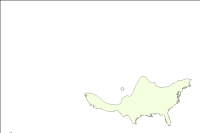

<Item title:"Aedes Worldwide Points" type:Feature Layer Collection owner:dattaway_wdcintel>
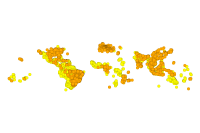

<Item title:"SemZika" type:Feature Layer Collection owner:AdmProjEstr>
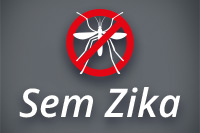

In [119]:
aedesitems = gis.content.search('Aedes aegypti', 'feature layer', outside_org=True, max_items=3)
for item in aedesitems:
    display(item)

In [122]:
aedessightings = aedesitems[1]

In [123]:
aedessightings.layers

[<FeatureLayer url:"https://services5.arcgis.com/cMBqYE4wmbXNMvex/arcgis/rest/services/Aedes_Worldwide_Points/FeatureServer/0">]